<a href="https://colab.research.google.com/github/BalasA90/Product_category_classification/blob/main/notebook/product_category_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Product Category Classification

This project aims to classify products into categories based on their titles using Machine Learning techniques.

The dataset contains product-related information such as:
- product title
- merchant ID
- category label
- product code
- number of views
- merchant rating
- listing date

The main objective is to use the **product title** as input text and predict the corresponding **product category**.


## 1. Import Libraries

In this step, we import the Python libraries required for:
- data analysis
- data visualization
- text vectorization
- model training
- model evaluation

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC


## 2. Load the Dataset

The dataset is loaded directly from the GitHub repository using the raw CSV file link.


In [2]:
# load dataset from GitHub
url = "https://raw.githubusercontent.com/BalasA90/Product_category_classification/main/data/products.csv"
df = pd.read_csv(url)


## 3. Explore the Dataset

Before applying Machine Learning, it is important to inspect:
- the size of the dataset
- the first rows
- the column information



In [3]:
print("Dataset shape (rows, columns):", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset info:")
df.info()

Dataset shape (rows, columns): (35311, 8)

First 5 rows:


,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35311 entries, 0 to 35310
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product ID       35311 non-null  int64  
 1   Product Title    35139 non-null  object 
 2   Merchant ID      35311 non-null  int64  
 3    Category Label  35267 non-null  object 
 4   _Product Code    35216 non-null  object 
 5   Number_of_Views  35297 non-null  float64
 6   Merchant Rating  35141 non-null  float64
 7    Listing Date    35252 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 2.2+ MB



## 4. Clean and Standardize Column Names

The original dataset contains column names with spaces and inconsistent formatting.

To simplify further analysis, the column names are standardized using:
- lowercase letters
- underscores instead of spaces
- removal of leading and trailing spaces



In [4]:
print("Original column names:")
print(df.columns)

df.columns = df.columns.astype(str)
df.columns = df.columns.str.strip()
df.columns = df.columns.str.strip('_')
df.columns = df.columns.str.replace('_', ' ', regex=False)
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True)
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_', regex=False)
df.columns = df.columns.str.strip('_')

print("\nStandardized column names:")
print(df.columns)


Original column names:
Index(['product ID', 'Product Title', 'Merchant ID', ' Category Label',
       '_Product Code', 'Number_of_Views', 'Merchant Rating',
       ' Listing Date  '],
      dtype='object')

Standardized column names:
Index(['product_id', 'product_title', 'merchant_id', 'category_label',
       'product_code', 'number_of_views', 'merchant_rating', 'listing_date'],
      dtype='object')



## 5. Check Dataset Dimensions

After cleaning the column names, we verify the number of rows and columns again.



In [5]:

print("Dataset shape:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset shape:
Rows: 35311
Columns: 8


## 6. Missing Values Analysis

Missing values may negatively affect the training process and model performance.

In this step, we calculate:
- the number of missing values
- the percentage of missing values for each column


In [6]:
missing_values = df.isna().sum().to_frame(name="missing_values")
missing_values["percentage"] = (missing_values["missing_values"] / len(df)) * 100

print("Missing values per column:")
display(missing_values)

Missing values per column:


,missing_values,percentage
product_id,0,0.000000
product_title,172,0.487100
merchant_id,0,0.000000
category_label,44,0.124607
product_code,95,0.269038
number_of_views,14,0.039648
merchant_rating,170,0.481436
listing_date,59,0.167087


## 7. Remove Rows with Missing Values

To ensure that the model is trained on complete data only, rows containing missing values are removed.


In [7]:
df = df.dropna()

print("Dataset shape after dropping missing values:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

missing_values_after = df.isna().sum().to_frame(name="missing_values")
missing_values_after["percentage"] = (missing_values_after["missing_values"] / len(df)) * 100

print("\nMissing values after cleaning:")
display(missing_values_after)



Dataset shape after dropping missing values:
Rows: 34760
Columns: 8

Missing values after cleaning:


,missing_values,percentage
product_id,0,0.0
product_title,0,0.0
merchant_id,0,0.0
category_label,0,0.0
product_code,0,0.0
number_of_views,0,0.0
merchant_rating,0,0.0
listing_date,0,0.0


## 8. Clean the Target Labels

Some categories appear in slightly different forms, such as singular and plural versions.

Examples:
- `CPU` and `CPUs`
- `Mobile Phone` and `Mobile Phones`

These inconsistencies can affect model performance, so they are standardized

In [8]:
print("Original category labels:")
print(df["category_label"].value_counts())


df["category_label"] = df["category_label"].replace({
    "CPU": "CPUs",
    "Mobile Phone": "Mobile Phones"
})


print("Cleaned category labels:")
print(df["category_label"].value_counts())


Original category labels:
category_label
Fridge Freezers     5424
Washing Machines    3971
Mobile Phones       3970
CPUs                3711
TVs                 3502
Fridges             3403
Dishwashers         3374
Digital Cameras     2661
Microwaves          2307
Freezers            2182
fridge               121
CPU                   81
Mobile Phone          53
Name: count, dtype: int64
Cleaned category labels:
category_label
Fridge Freezers     5424
Mobile Phones       4023
Washing Machines    3971
CPUs                3792
TVs                 3502
Fridges             3403
Dishwashers         3374
Digital Cameras     2661
Microwaves          2307
Freezers            2182
fridge               121
Name: count, dtype: int64


## 9. Analyze Category Distribution

In this step, we examine how many products belong to each category.

This helps us understand whether the dataset is balanced or whether some categories contain much fewer samples.

In [9]:
category_counts = df["category_label"].value_counts()

print("Category distribution:")
print(category_counts)

Category distribution:
category_label
Fridge Freezers     5424
Mobile Phones       4023
Washing Machines    3971
CPUs                3792
TVs                 3502
Fridges             3403
Dishwashers         3374
Digital Cameras     2661
Microwaves          2307
Freezers            2182
fridge               121
Name: count, dtype: int64


## 10. Visualize Category Distribution

A bar chart is used to visualize the number of products in each category.



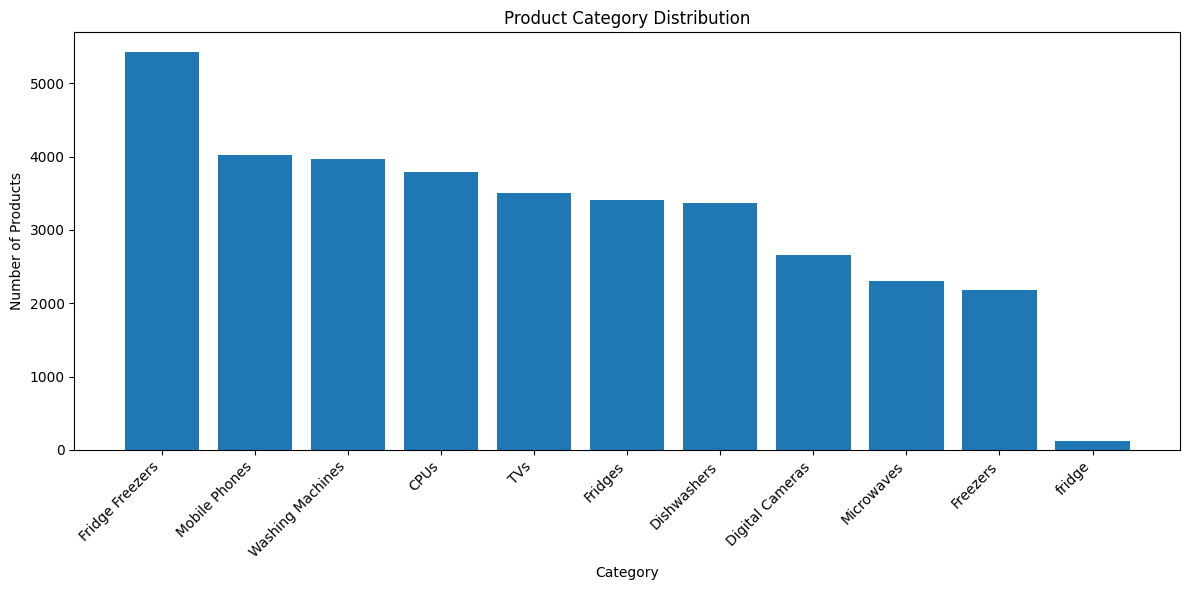

In [10]:
plt.figure(figsize=(12, 6))
plt.bar(category_counts.index, category_counts.values)
plt.title("Product Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 11. Clean the Product Titles

Since the model will use `product_title` as input text, the text must be cleaned first.

The following preprocessing steps are applied:
- convert text to lowercase
- remove punctuation
- remove numbers
- remove extra spaces


In [11]:
df["product_title_cleaned"] = (
    df["product_title"]
    .astype(str)
    .str.lower()
    .str.replace(r"[^\w\s]", "", regex=True)
    .str.replace(r"\d+", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print("Original vs cleaned product titles:")
display(df[["product_title", "product_title_cleaned"]].head())


Original vs cleaned product titles:


,product_title,product_title_cleaned
0,apple iphone 8 plus 64gb silver,apple iphone plus gb silver
1,apple iphone 8 plus 64 gb spacegrau,apple iphone plus gb spacegrau
2,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,apple mqnba iphone plus gb mp sim free smartph...
3,apple iphone 8 plus 64gb space grey,apple iphone plus gb space grey
4,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,apple iphone plus gold gb g unlocked sim free


## 12. Define Features and Target

The cleaned product title is used as the input feature (`x`), while the product category is used as the target variable (`y`).


In [12]:

x = df["product_title_cleaned"]
y = df["category_label"]

print("Feature sample:")
print(x.head())

print("\nTarget sample:")
print(y.head())

Feature sample:
0                          apple iphone plus gb silver
1                       apple iphone plus gb spacegrau
2    apple mqnba iphone plus gb mp sim free smartph...
3                      apple iphone plus gb space grey
4        apple iphone plus gold gb g unlocked sim free
Name: product_title_cleaned, dtype: object

Target sample:
0    Mobile Phones
1    Mobile Phones
2    Mobile Phones
3    Mobile Phones
4    Mobile Phones
Name: category_label, dtype: object


## 13. Split the Dataset into Training and Testing Sets

The dataset is divided into:
- 80% training data
- 20% testing data

The `stratify=y` argument ensures that the class distribution remains similar in both sets.



In [13]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", x_train.shape[0])
print("Testing set size:", x_test.shape[0])

Training set size: 27808
Testing set size: 6952


## 14. Convert Text into Numerical Features Using TF-IDF

Machine Learning algorithms cannot work directly with raw text.

Therefore, the cleaned product titles are transformed into numerical vectors using TF-IDF (Term Frequency - Inverse Document Frequency).



In [14]:
vectorizer = TfidfVectorizer(stop_words="english")

x_train_tfidf = vectorizer.fit_transform(x_train)
x_test_tfidf = vectorizer.transform(x_test)

print("TF-IDF training matrix shape:", x_train_tfidf.shape)
print("TF-IDF testing matrix shape:", x_test_tfidf.shape)


TF-IDF training matrix shape: (27808, 8697)
TF-IDF testing matrix shape: (6952, 8697)


## 15. Train and Compare Multiple Machine Learning Models

To identify the best approach for this classification task, multiple machine learning algorithms are trained and evaluated.

The following models are used:
- Logistic Regression
- Naive Bayes
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)

In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": LinearSVC(random_state=42)
}



## 16. Train the Models and Evaluate Their Performance

Each model is trained on the TF-IDF training data, then evaluated on the testing set using:
- accuracy
- precision
- recall
- f1-score


In [16]:
results = {}
trained_models = {}

for name, model in models.items():
    print("\n" + "=" * 50)
    print(f"Model: {name}")

    model.fit(x_train_tfidf, y_train)
    y_pred = model.predict(x_test_tfidf)

    trained_models[name] = model
    results[name] = accuracy_score(y_test, y_pred)

    print(f"Accuracy: {results[name]:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))




Model: Logistic Regression
Accuracy: 0.9639

Classification Report:
                  precision    recall  f1-score   support

            CPUs       1.00      0.99      1.00       758
 Digital Cameras       1.00      0.99      1.00       532
     Dishwashers       0.94      0.97      0.96       675
        Freezers       0.99      0.93      0.96       436
 Fridge Freezers       0.95      0.95      0.95      1085
         Fridges       0.91      0.92      0.91       681
      Microwaves       0.98      0.97      0.98       461
   Mobile Phones       0.96      0.99      0.98       805
             TVs       0.98      0.98      0.98       701
Washing Machines       0.96      0.96      0.96       794
          fridge       0.00      0.00      0.00        24

        accuracy                           0.96      6952
       macro avg       0.88      0.88      0.88      6952
    weighted avg       0.96      0.96      0.96      6952


Model: Naive Bayes
Accuracy: 0.9438

Classification Repor

## 17. Compare Model Accuracy

The accuracy of all trained models is compared in order to identify the best-performing algorithm.



Model comparison:


,Model,Accuracy
4,SVM,0.972382
0,Logistic Regression,0.963895
3,Random Forest,0.962313
2,Decision Tree,0.951525
1,Naive Bayes,0.943757


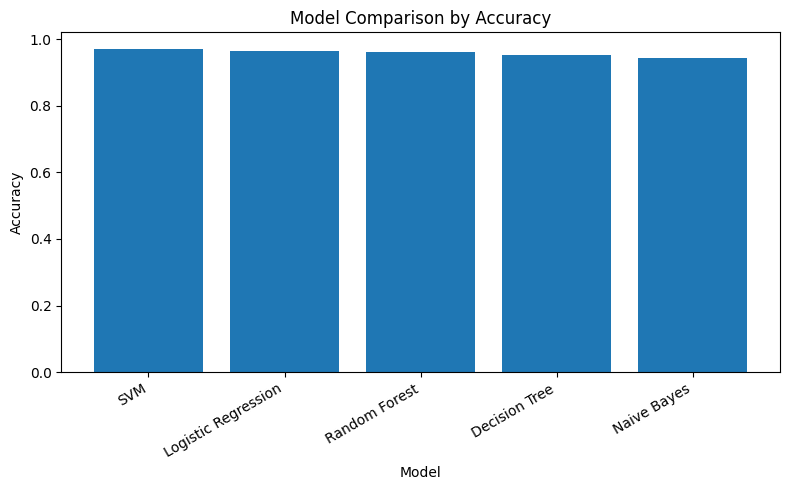

In [17]:
results_df = pd.DataFrame(
    list(results.items()),
    columns=["Model", "Accuracy"]
).sort_values(by="Accuracy", ascending=False)

print("Model comparison:")
display(results_df)



plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Comparison by Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()



## 18. Select the Best Model

The best model is selected based on the highest accuracy score.


In [18]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)
print("Best accuracy:", results_df.iloc[0]["Accuracy"])


Best model: SVM
Best accuracy: 0.9723820483314154


## 19. Confusion Matrix for the Best Model

The confusion matrix helps visualize how many products were classified correctly and where the model made mistakes.

Confusion Matrix:
[[ 755    0    0    0    0    0    0    2    1    0    0]
 [   0  530    0    0    0    0    0    2    0    0    0]
 [   0    0  660    1    2    0    3    0    0    9    0]
 [   0    0    0  419    5    6    1    0    0    5    0]
 [   0    0   12    1 1043   11    2    6    2    8    0]
 [   0    0    1    4   33  636    0    2    0    3    2]
 [   0    0    2    0    0    0  453    2    0    4    0]
 [   1    2    0    0    0    1    0  799    2    0    0]
 [   0    0    0    0    0    0    1   10  690    0    0]
 [   0    0   12    0    1    2    2    2    0  775    0]
 [   0    0    0    0    2   22    0    0    0    0    0]]


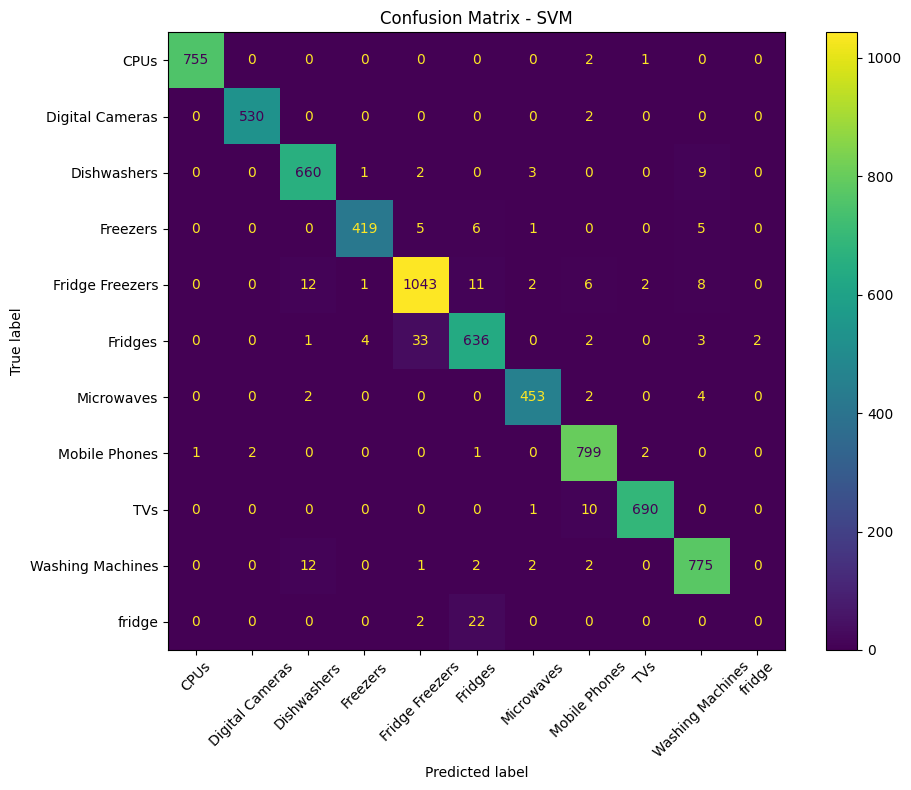

In [19]:
best_y_pred = best_model.predict(x_test_tfidf)
cm = confusion_matrix(y_test, best_y_pred)

print("Confusion Matrix:")
print(cm)


fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(ax=ax, xticks_rotation=45)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

## 20. Test the Best Model on New Product Titles

Finally, the best model is tested on new product titles that were not part of the dataset.


In [20]:
new_products = [
    "iphone 14 pro max 256gb",
    "lg smart tv 55 inch",
    "samsung washing machine 8kg",
    "canon digital camera eos",
    "double door fridge freezer"
]


new_products_series = pd.Series(new_products)

new_products_cleaned = (
    new_products_series
    .astype(str)
    .str.lower()
    .str.replace(r"[^\w\s]", "", regex=True)
    .str.replace(r"\d+", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

new_products_tfidf = vectorizer.transform(new_products_cleaned)
predicted_categories = best_model.predict(new_products_tfidf)

print("Predictions for new product titles:")
for product, category in zip(new_products, predicted_categories):
    print(f"{product} --> {category}")


Predictions for new product titles:
iphone 14 pro max 256gb --> Mobile Phones
lg smart tv 55 inch --> TVs
samsung washing machine 8kg --> Washing Machines
canon digital camera eos --> Digital Cameras
double door fridge freezer --> Fridge Freezers


## 21. Conclusion

This project demonstrated how Machine Learning can be used to classify products into categories based only on their titles.

The dataset was cleaned, preprocessed, and transformed into TF-IDF numerical features.  
Several machine learning models were trained and compared:
- Logistic Regression
- Naive Bayes
- Decision Tree
- Random Forest
- Support Vector Machine

The best-performing model achieved the highest accuracy on the testing set, showing that product titles contain enough relevant information for category prediction.

The results confirm that text classification techniques can be successfully applied to product categorization tasks.

Possible future improvements include:
- better cleaning of category labels
- hyperparameter tuning
- more advanced text preprocessing
- using larger and more balanced datasets

